In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [2]:
from ucimlrepo import fetch_ucirepo 
online_retail = fetch_ucirepo(id=352) 
df = online_retail.data.features 

In [3]:
df.shape

(541909, 6)

In [4]:
df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
numerical_features = df.select_dtypes(include=[np.number]).columns
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].mean())
df.isnull().sum()

C:\Users\vansh\AppData\Local\Temp\ipykernel_23776\134280051.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numerical_features] = df[numerical_features].fillna(df[numerical_features].mean())


Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64

In [28]:
# Sample 5000 rows for DBSCAN 
# df_sampled = df.sample(n=5000, random_state=42)
df_sampled = df.sample(n=5000)

In [29]:
x_sampled = df_sampled[numerical_features]
scaler = StandardScaler()
sc_x_sampled = scaler.fit_transform(x_sampled)

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
sc_x_sampled_reduced = pca.fit_transform(sc_x_sampled)


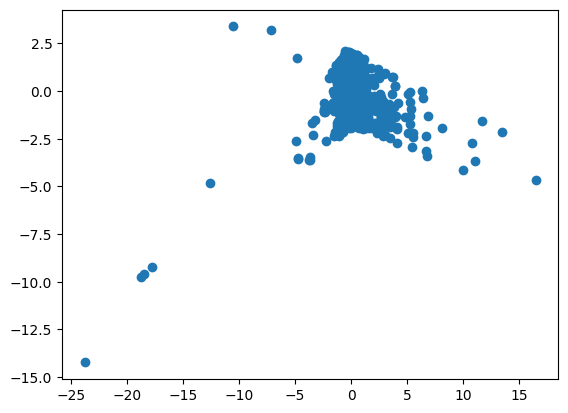

In [31]:
plt.scatter(sc_x_sampled_reduced[:,0],sc_x_sampled_reduced[:,1])

In [39]:
db = DBSCAN(eps=0.8, min_samples=5)
cluster = db.fit_predict(sc_x_sampled_reduced)
df_sampled['Cluster'] = cluster

In [40]:
print(df_sampled['Cluster'].value_counts())

Cluster
 0    4952
-1      37
 2       6
 1       5
Name: count, dtype: int64


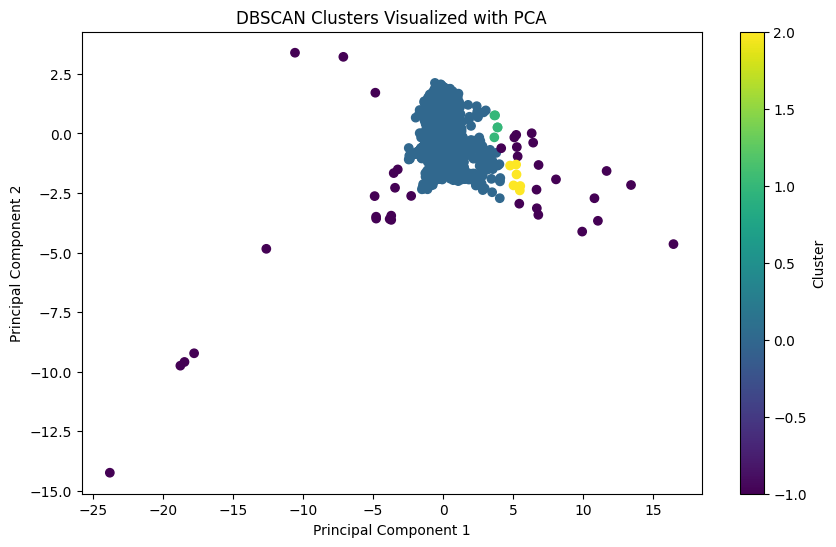

In [41]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(sc_x_sampled_reduced)

plt.figure(figsize=(10, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=df_sampled['Cluster'], cmap='viridis')
plt.title('DBSCAN Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [42]:
print(df_sampled.groupby('Cluster').mean(numeric_only=True))

           Quantity  UnitPrice    CustomerID
Cluster                                     
-1       129.594595  36.316216  15080.509027
 0         8.207997   3.162130  15265.649084
 1       146.400000   1.600000  17513.000000
 2       191.166667   1.508333  14430.948428


In [43]:
from sklearn.metrics import silhouette_score
mask = df_sampled['Cluster'] != -1
if len(df_sampled['Cluster'].unique()) > 1 and mask.sum() > 0:
    score = silhouette_score(sc_x_sampled_reduced[mask], df_sampled['Cluster'][mask])
    print(f"Silhouette Score: {score}")
else:
    print("Silhouette Score: Not applicable (only 1 cluster or all noise)")

Silhouette Score: 0.7231311793634031


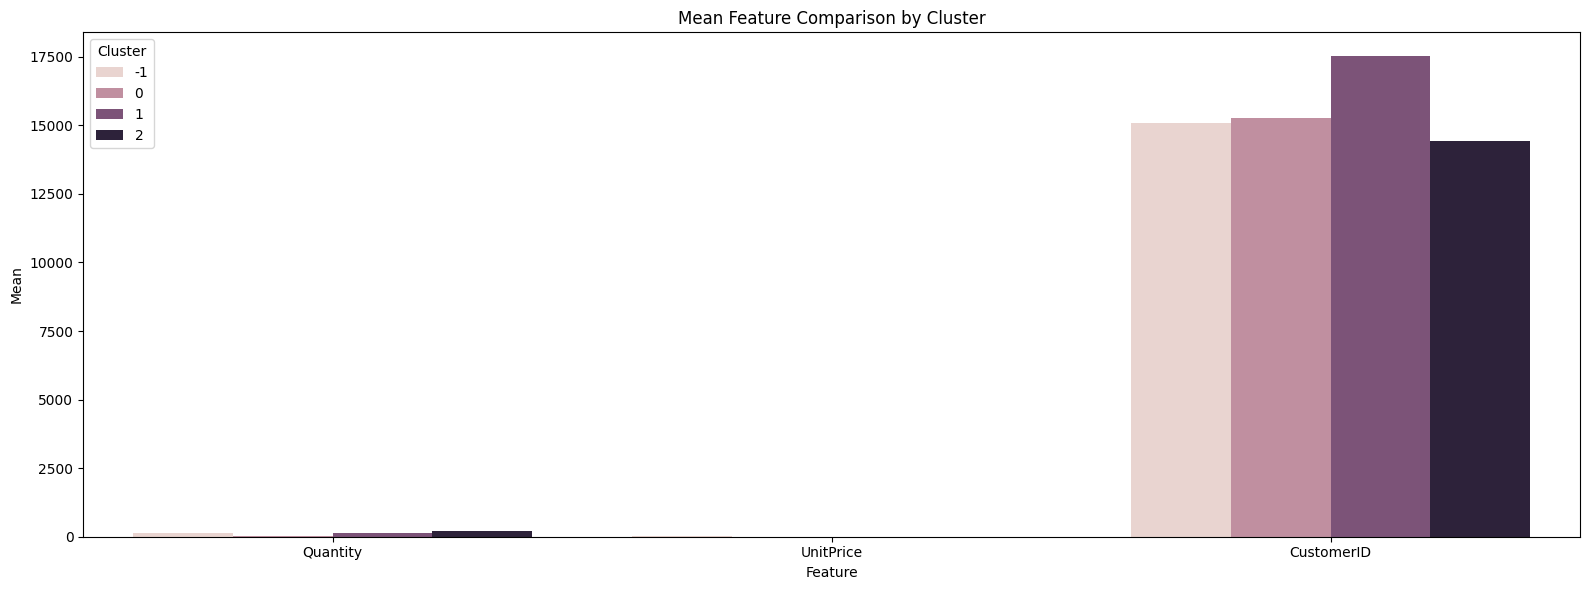

In [44]:
import seaborn as sns
cluster_means = df_sampled.groupby('Cluster').mean(numeric_only=True)
mean_df = cluster_means.reset_index().melt(id_vars='Cluster', var_name='Feature', value_name='Mean')
plt.figure(figsize=(16, 6))
sns.barplot(data=mean_df, x='Feature', y='Mean', hue='Cluster')
plt.title('Mean Feature Comparison by Cluster')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
x = df_sampled[numerical_features]
y = df_sampled['Cluster']

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [48]:
regressor = RandomForestClassifier()

In [49]:
parameters = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

In [57]:
dcv = GridSearchCV(regressor, param_grid=parameters, cv=5, scoring='accuracy')

In [58]:
dcv.fit(x_train,y_train)

d:\jbook\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [59]:
dcv.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}

In [60]:
print(dcv.best_score_)

0.9984000000000002


In [61]:
y_pred = dcv.predict(x_test)

In [62]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [63]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.7894648195713503
MAE: 0.0032
MSE: 0.0032
